# Actividad 1



Esta actividad consiste en la realización de la actividad evaluable número 1 asociada al bloque 1 de la asignatura. En ella, se realizará un ejercicio de clasificaciónn, empleando 3 métodos: Naive Bayes, K-NN y Árboles de Decisión.

## Importación de Librerías

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source

## Carga de los Datos

Tal y como menciona el enunciado, los datos provienen de la web InsideAirbnb, dedicada al estudio de alquileres vacacionales ofrecidos en la plataforma Airbnb. El fichero es una versión editada de los datos de Madrid en abril de 2017.

Cargamos los datos y mostraremos una vista previa:

In [88]:
# Carga de datos
df = pd.read_csv('airbnb.csv')
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Centro,Justicia,40.424715,-3.698638,Entire home/apt,49,28,35,0.42,1,99
1,Centro,Embajadores,40.413418,-3.706838,Entire home/apt,80,5,18,0.30,1,188
2,Moncloa - Aravaca,Argüelles,40.424920,-3.713446,Entire home/apt,40,2,21,0.25,9,195
3,Moncloa - Aravaca,Casa de Campo,40.431027,-3.724586,Entire home/apt,55,2,3,0.13,9,334
4,Latina,Cármenes,40.403410,-3.740842,Private room,16,2,23,0.76,2,250
...,...,...,...,...,...,...,...,...,...,...,...
13316,Centro,Justicia,40.427500,-3.698354,Private room,14,1,0,0.00,1,10
13317,Chamberí,Gaztambide,40.431187,-3.711909,Entire home/apt,47,1,0,0.00,7,354
13318,Centro,Palacio,40.413552,-3.711461,Entire home/apt,60,2,0,0.00,1,17
13319,Centro,Universidad,40.425400,-3.709921,Entire home/apt,150,5,0,0.00,1,15


Tenemos 13321 entradas de datos, con 11 columnas. 

Tras analizar la vista previa, concluimos que esta es la descripción de cada una de las columnas:

| **Columna**                               | **Descripción**                                                                       |
|-------------------------------------------|---------------------------------------------------------------------------------------|
| neighbourhood_group                       | Agrupación de vecindario en la que se encuentra la propiedad.                         |
| neighbourhood                             | Nombre del vecindario de la propiedad (más exacto).                                   |
| latitude                                  | Latitud geográfica.                                                                   |
| longitude                                 | Longitud geográfica.                                                                  |
| room_type                                 | Tipo de habitación ofrecida (entera, privada, compartida).                            |
| price                                     | Precio por noche.                                                                     |
| minimum_nights                            | Número mínimo de noches requeridas para reservar.                                     |
| number_of_reviews                         | Cantidad total de reseñas.                                                            |
| reviews_per_month                         | Cantidad promedio de reseñas mensualmente.                                            |
| calculated_host_listings_count            | Número total de listados que posee el anfitrión en Airbnb.                            |
| availability_365                          | Número de días al año en que la propiedad está disponible para ser alquilada.         |

La tarea consiste en clasificar los datos según el tipo de alojamiento (columna `room_type`) a partir del resto de características.

## Estudio Estadístico Inicial

Comenzaremos realizando un análisis exploratorio de los datos (o *Exploratory Data Analysis* - EDA en inglés).

### Información del Dataframe: tipos de datos, valores nulos, duplicados

El método `.info()` nos proporciona un resumen del DataFrame, mostrando el numero de filas, el nombre de cada columna, tipos de datos y número de valores no nulos que tenemos.

In [89]:
# Ver información del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13321 entries, 0 to 13320
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             13321 non-null  object 
 1   neighbourhood                   13321 non-null  object 
 2   latitude                        13321 non-null  float64
 3   longitude                       13321 non-null  float64
 4   room_type                       13321 non-null  object 
 5   price                           13321 non-null  int64  
 6   minimum_nights                  13321 non-null  int64  
 7   number_of_reviews               13321 non-null  int64  
 8   reviews_per_month               13321 non-null  float64
 9   calculated_host_listings_count  13321 non-null  int64  
 10  availability_365                13321 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 1.1+ MB


El resultado nos muestra que todos los campos en el DataFrame tienen valores completos (no nulos). Los tipos de datos son `int64`, `float64` y `object`.

Convertiremos las columnas de tipo `object` a tipos categóricos:

In [90]:
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')
df['room_type'] = df['room_type'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13321 entries, 0 to 13320
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   neighbourhood_group             13321 non-null  category
 1   neighbourhood                   13321 non-null  category
 2   latitude                        13321 non-null  float64 
 3   longitude                       13321 non-null  float64 
 4   room_type                       13321 non-null  category
 5   price                           13321 non-null  int64   
 6   minimum_nights                  13321 non-null  int64   
 7   number_of_reviews               13321 non-null  int64   
 8   reviews_per_month               13321 non-null  float64 
 9   calculated_host_listings_count  13321 non-null  int64   
 10  availability_365                13321 non-null  int64   
dtypes: category(3), float64(3), int64(5)
memory usage: 877.6 KB


Pese a que hayamos revisado el número de valores no nulos en la sección anterior, también podemos utilizar `isnull().sum()` para hacer un conteo de los valores nulos en cada columna, y de este modo, confirmar el resultado de nuevo:

In [91]:
# Valores nulos
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

No hay ningún valor nulo, por lo que no es necesario hacer una limpieza o imputación en este sentido.

Ahora comprobaremos si nuestro DataFrame contiene valores duplicados:

In [92]:
df.duplicated().sum()

0

No contiene ningún valor duplicado.

### Análisis de las Variables Numéricas

A continuación exploramos la estadística descriptiva de las columnas numéricas utilizando `df.describe()`:

In [93]:
# Ver estadística descriptiva
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000
mean,40.420730,-3.697268,69.171834,3.010885,22.986037,1.520329,7.605885,205.867202
std,0.020344,0.023832,103.721126,12.835619,38.406006,1.852367,19.619972,126.968961
min,40.331888,-3.863907,9.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.410090,-3.707856,31.000000,1.000000,1.000000,0.110000,1.000000,84.000000
50%,40.418731,-3.701602,53.000000,2.000000,7.000000,0.780000,2.000000,247.000000
75%,40.427997,-3.693818,80.000000,3.000000,28.000000,2.320000,4.000000,321.000000
max,40.562736,-3.526821,7700.000000,1125.000000,446.000000,17.210000,145.000000,365.000000


El resultado nos da un resumen de la distribución de las variables numéricas. Los valores parecen estar dentro de lo esperado, y a simple vista parece que hay pocos outliers. 

**Notas por cada columna:**

- Las coordenadas (latitud y longitud) indican que las propiedades están concentradas en un rango estrecho correspondiente a Madrid.
- El precio abarca un amplio rango, entre 9 y 7700 euros por noche, aunque la mayoría están por debajo de los 80 euros (ver que 75% es 80). 7700 euros/noche podría ser un outlier.
- La cantidad de noches mínimas está entre 1 y 1125, aunque la mayoría (75%) tan solo exigen 3 noches mínimas. Dado que hablamos de apartamentos y casas, estos valores tienen sentido.
- Tanto el número de reseñas como el la cantidad de reseñas al mes no destacan. La mayoría de las propiedades apenas tienen reseñas. Sin embargo, hay otras con muchas (muy populares).
- En cuanto al número total de listados que posee el anfitrión en Airbnb, vemos que la mayoría de los anfitriones (75%) poseen 4 o menos. Sin embargo, hay algunos con más, siendo el máximo 145.
- La disponibilidad está entre 0 (no disponible) y 365 (disponible todo el año). El rango de valores está dentro del número de días del año.

Ahora veremos la distribución de estas variables numéricas en formato de gráfico, para intentar obtener más detalle:

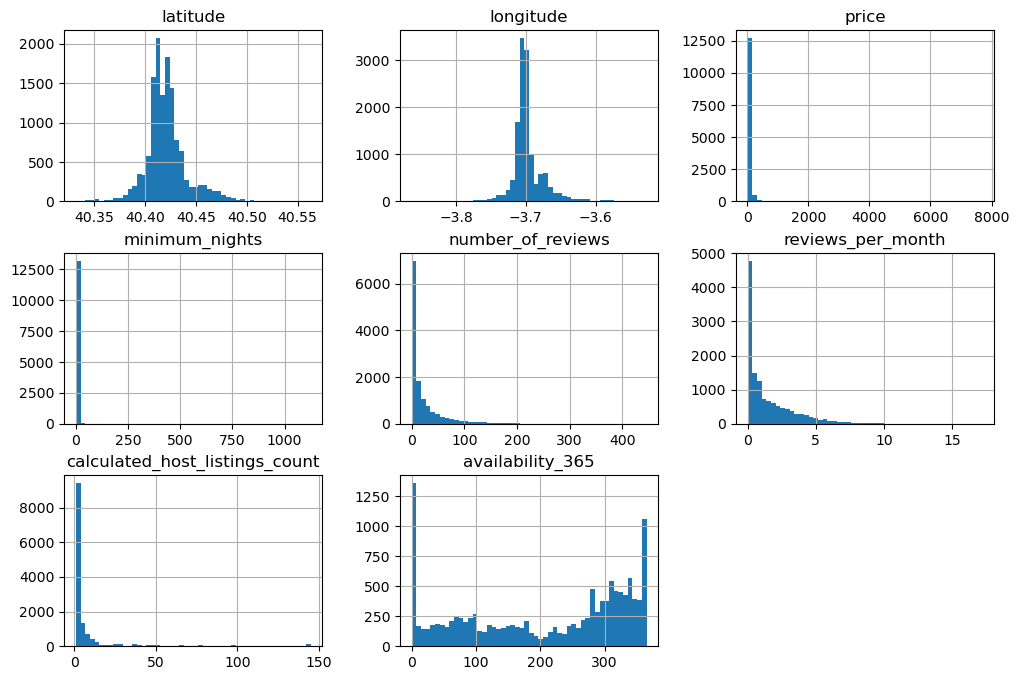

In [94]:
df.hist(bins=50, figsize=(12, 8))
plt.show()

Con estos gráficos confirmamos lo visto mediante `df.describe()`. Además, podemos obtener un poco más de información sobre la distribución de las variables, como:
- La latitud y longitud están sobre todo centradas en unas ubicaciones concretas. Su distribución se asemeja a una distribución normal.
- En cuanto a precio, confirmamos que la mayoría están por debajo de los 80 euros. El valor de 7700 euros parece ser un outlier.
- Confirmamos que la mayoría exigen una cantidad muy baja de noches mínimas. En este caso también, el valor máximo es de 1125, que parece ser un outlier. Esto tendría sentido teniendo en cuenta que son alquileres vacacionales.
- La mayoría de los alojamientos tienen un número de reseñas y promedio de reseñas mensuales bajo. Ambas variables parecen seguir la misma distribución, y la lógica nos dice que pueden estar correlacionadas porque se calculan a partir de un mismo total de reseñas.
- Confirmamos que la mayoría de los anfitriones poseen pocos listados.
- La distribución de la disponibilidad está distribuida de forma más o menos uniforme, con dos picos a los lados. Hay mayor frecuencia en alojamientos que están siempre disponibles (365) o nunca (0).

Analizaremos si hay correlación entre las variables numéricas:

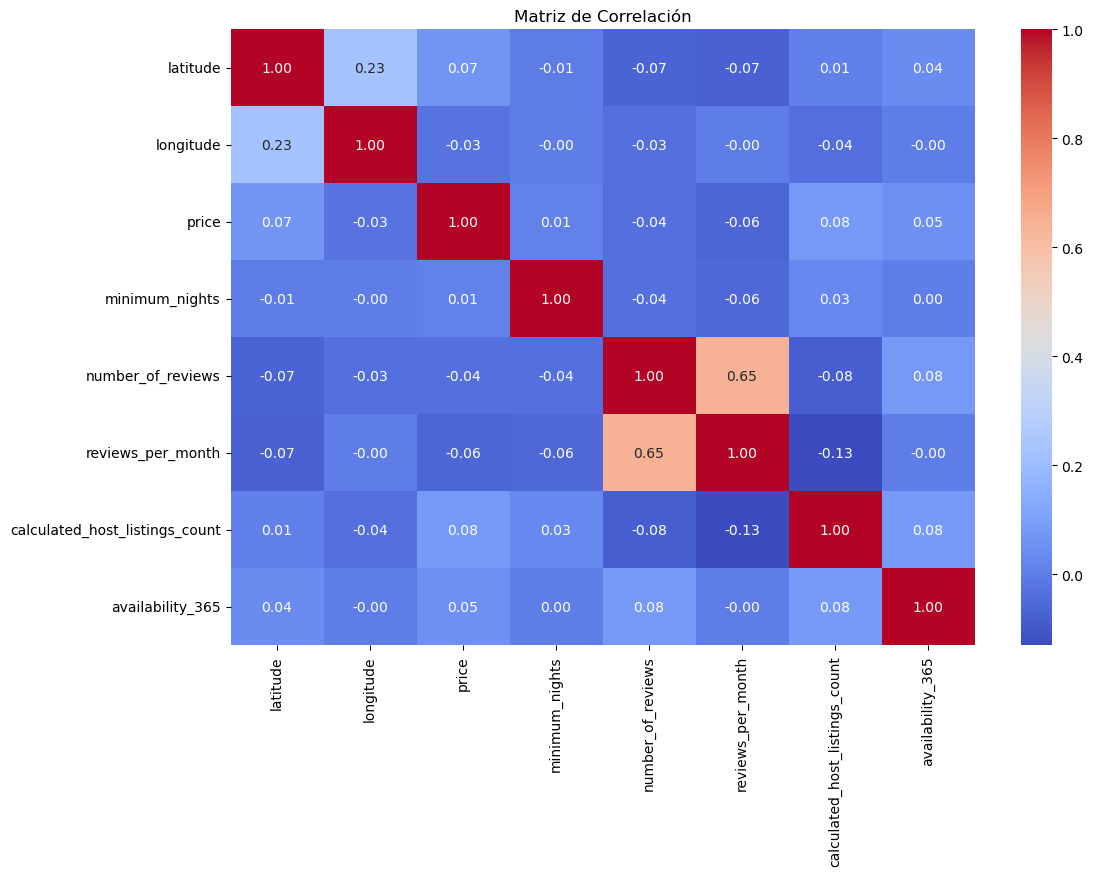

In [95]:
# Matriz de correlacion
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

Concluimos que, efectivamente, hay una correlación entre el número de reseñas totales (`number_of_reviews`) y el promedio de reseñas mensuales (`reviews_per_month`).

Visualizaremos también la distribución de la ubicación en base a la latitud y longitud, y estableceremos `alpha=2` para ver la densidad de cada área:

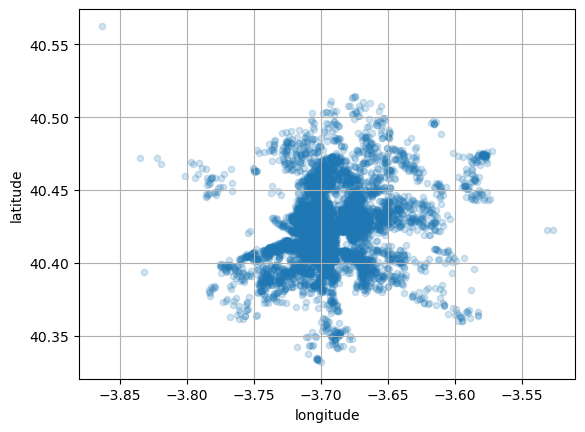

In [96]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

Vemos que el resultado se parece al mapa de Madrid, y que los áreas con más densidad están en el centro.

Ahora intentaremos ver si hay una correlación entre los precios y la ubicación, pintando los puntos según los precios:

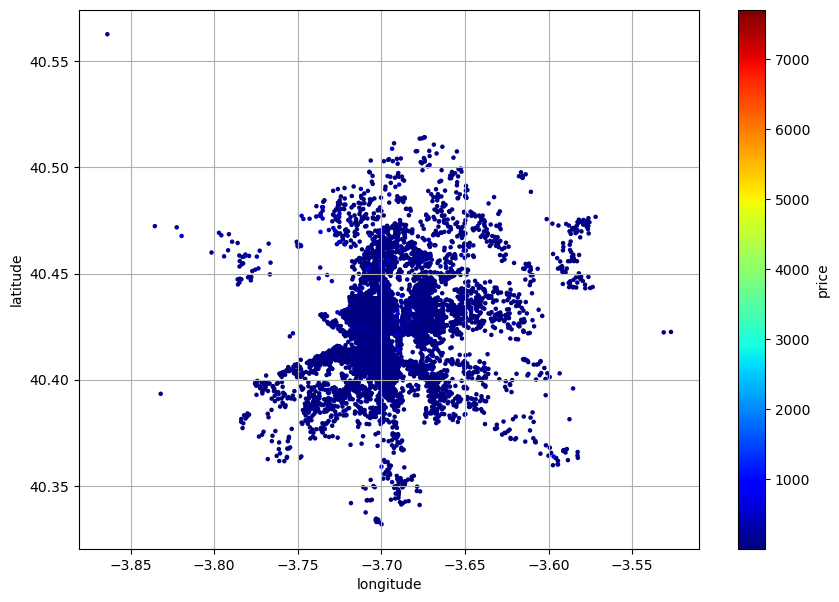

In [97]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True,
        c="price", cmap="jet", colorbar=True, s=5,
       legend=True, sharex=False, figsize=(10, 7))
plt.show()

En esta visualización no se ven conclusiones claras. Esto se debe a que el 75% de las propiedades tienen un precio inferior a 80 euros, lo que hace que casi todos los puntos que se ven sean de un color muy oscuro.

Si filtramos nuestro dataset para sólo mostrar aquellas entradas que tengan un precio inferior a 200 euros, obtenemos una mejor resolución en cuanto a los colores:

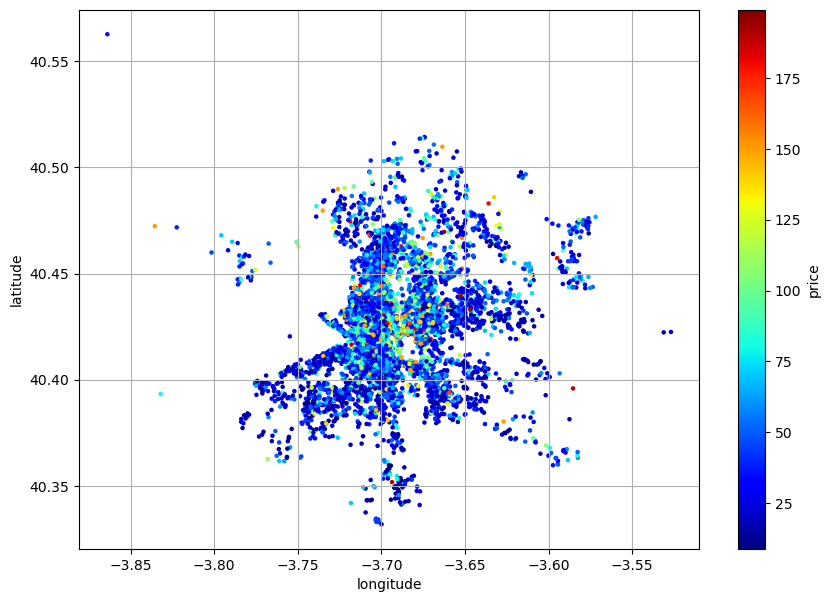

In [98]:
df_filtered = df[df["price"] < 200]
df_filtered.plot(kind="scatter", x="longitude", y="latitude", grid=True,
        c="price", cmap="jet", colorbar=True, s=5,
       legend=True, sharex=False, figsize=(10, 7))
plt.show()

En esta visualización se intuye que las propiedades del centro tienen precios más elevados.

### Análisis de Variables Categóricas

Analicemos ahora los valores de las variables categóricas. Realizaremos un conteo de cada categoría y miraremos el porcentaje total.

Comenzaremos con `neighbourhood_group`:

In [99]:
# Contar por neighbourhood_group y calcular el % total
count_neighbourhood_group = df["neighbourhood_group"].value_counts().reset_index()
count_neighbourhood_group.columns = ['neighbourhood_group', 'count']
count_neighbourhood_group['%'] = (count_neighbourhood_group['count'] / count_neighbourhood_group['count'].sum()) * 100
count_neighbourhood_group

,neighbourhood_group,count,%
0,Centro,6773,50.844531
1,Chamberí,960,7.206666
2,Salamanca,883,6.628631
3,Arganzuela,790,5.930486
4,Tetuán,463,3.475715
5,Moncloa - Aravaca,450,3.378125
6,Retiro,439,3.295548
7,Latina,379,2.845132
8,Chamartín,361,2.710007
9,Carabanchel,358,2.687486


Vemos que la mayoría de las viviendas están ubicadas en el centro.

A continuación analizaremos `neighbourhood`:

In [100]:
# Contar por neighbourhood y calcular el % total
count_neighbourhood = df["neighbourhood"].value_counts().reset_index()
count_neighbourhood.columns = ['neighbourhood', 'count']
count_neighbourhood['%'] = (count_neighbourhood['count'] / count_neighbourhood['count'].sum()) * 100
count_neighbourhood

,neighbourhood,count,%
0,Embajadores,1848,13.872832
1,Universidad,1363,10.231965
2,Palacio,1084,8.137527
3,Sol,942,7.071541
4,Justicia,788,5.915472
...,...,...,...
121,Rosas,4,0.030028
122,Hellín,4,0.030028
123,Cuatro Vientos,3,0.022521
124,Orcasitas,2,0.015014


En cuanto al análsis de los vecindarios, vemos que hay muchos vecindarios (126 en total). Esta variable `neighbourhood` está muy relacionada con la anterior `neighbourhood_group` y, a simple vista, puede parecer redundante. Sin embargo, nos aporta más detalle que el anterior, y de entrada, es interesante probar cómo actúan los modelos con ambas columnas.

También es interesante resaltar que las variables `latitude` y `longitude` representan la ubicación, y que pueden parecer solaparse también con estas variables `neighbourhood` y `neighbourhood_group`. Sin embargo, en este caso también exploraremos cómo actúan los modelos con todos estos datos antes de tomar alguna decisión de eliminación de variables.

Ahora analicemos `room_type`:

In [101]:
# Contar por room_type y calcular el % total
count_room_type = df["room_type"].value_counts().reset_index()
count_room_type.columns = ['room_type', 'count']
count_room_type['%'] = (count_room_type['count'] / count_room_type['count'].sum()) * 100
count_room_type

,room_type,count,%
0,Entire home/apt,7926,59.500038
1,Private room,5203,39.058629
2,Shared room,192,1.441333


`room_type`, es nuestra variable objetivo. En los resultados vemos que las clases están desbalanceadas, dado que la mayoría de las instancias son de apartamentos/casas enteras (`Entire home/apt`), y hay muy pocas que corresponden a habitaciones compartidas (`Shared room`). Teniendo en cuenta que los datos representan alquileres vacacionales, tiene sentido que la oferta de `Shared room` sea baja, dado que no es lo habitual alquilar una habitación compartida para vacaciones.

Este desbalanceo puede llevar que un modelo ignore las clases menos representadas, resultando en un rendimiento deficiente. Por lo tanto, tal y como el enunciado indica, consideraremos utilizar mecanismos de los propios algoritmos de clasificación para intentar contrarestar este problema.

## Preprocesamiento de Datos

En esta fase nos centraremos en limpiar, dividir y transformar el conjunto de datos, para obtener los datos de entrada necesarios para los modelos de Aprendizaje Automático.


### Eliminar Outliers

Eliminaremos los outliers máximos en las columnas `price` y `minimum_nights` detectadas en la fase de Estudio Estadístico para que los valores extremos no afecten negativamente al rendimiento del modelo:

In [102]:
df = df.drop(df['price'].idxmax())
df = df.drop(df['minimum_nights'].idxmax())
df.shape

(13319, 11)

No eliminaremos más outliers porque las demás variables no presentan desviaciones significativas según la información que tenemos y el conocimiento del dominio que disponemos.

### Dividir los datos en Conjunto de Entrenamiento y Test

Dividiremos los datos en conjunto de entrenamiento y test de manera que el conjunto de test sea un 20 % del total, tal y como lo solicita el enunciado. Para conservar una buena representación de las clases en esta división, haremos un muestreo estratificado basado en la columna `room_type`.

In [103]:
train_set, test_set = train_test_split(df, test_size = 0.2, stratify=df["room_type"], random_state = 0)

Comprobamos que efectivamente, las proporciones se mantienen en el `train_set` y `test_set`:

In [104]:
count_room_type_train = train_set["room_type"].value_counts().reset_index()
count_room_type_train.columns = ['room_type', 'count']
count_room_type_train['%'] = (count_room_type_train['count'] / count_room_type_train['count'].sum()) * 100
count_room_type_train

,room_type,count,%
0,Entire home/apt,6340,59.502581
1,Private room,4161,39.052088
2,Shared room,154,1.445331


In [105]:
count_room_type_test = test_set["room_type"].value_counts().reset_index()
count_room_type_test.columns = ['room_type', 'count']
count_room_type_test['%'] = (count_room_type_test['count'] / count_room_type_test['count'].sum()) * 100
count_room_type_test

,room_type,count,%
0,Entire home/apt,1585,59.496997
1,Private room,1041,39.076577
2,Shared room,38,1.426426


Dividimos los dataframes en `X` para variables (*features*) e `y` para la variable objetivo:

In [106]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'room_type'
y_train_set = train_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_train_set = train_set.drop(columns=['room_type'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'room_type'
y_test_set = test_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_test_set = test_set.drop(columns=['room_type'])

### Pipeline de Preprocesamiento de Datos

El *pipeline* de procesamiento de datos incluye:
- **Tratamiento de variables categóricas**: he utilizado OneHotEncoder como mejor estrategia de codificación posible. He descartado OrdinalEncoder porque asignar un número a cada categoría introduce un sesgo, ya que en este caso no existe un orden entre las categorías.
- **Escalado**: algunos algoritmos de Naive Bayes, como el MultinomialNB, no pueden trabajar con datos negativos. Por esta razón, se descarta el StandardScaler y utilizaremos el MinMaxScaler para asegurarnos de que el escalado se realice únicamente en rangos positivos.

La variable objetivo `room_type` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [107]:
num_attribs = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood"]

num_pipeline = Pipeline([
    ("minmax_scaler", MinMaxScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

Ajustamos el *preprocessing pipeline* a las características de `X_train_set` y luego transformamos tanto `X_train_set` como `X_test_set` aplicando las transformaciones definidas:

In [108]:
# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Es importante tener en cuenta que OneHotEncoder genera una gran cantidad de columnas o dimensiones, y esto incrementa el número de instancias necesarias para obtener un entrenamiento confiable. Estas son las columnas que tienen nuestros datos transformados:

In [109]:
# Nombres de las columnas
preprocessing.get_feature_names_out()

array(['num__latitude', 'num__longitude', 'num__price',
       'num__minimum_nights', 'num__number_of_reviews',
       'num__reviews_per_month', 'num__calculated_host_listings_count',
       'num__availability_365', 'cat__neighbourhood_group_Arganzuela',
       'cat__neighbourhood_group_Barajas',
       'cat__neighbourhood_group_Carabanchel',
       'cat__neighbourhood_group_Centro',
       'cat__neighbourhood_group_Chamartín',
       'cat__neighbourhood_group_Chamberí',
       'cat__neighbourhood_group_Ciudad Lineal',
       'cat__neighbourhood_group_Fuencarral - El Pardo',
       'cat__neighbourhood_group_Hortaleza',
       'cat__neighbourhood_group_Latina',
       'cat__neighbourhood_group_Moncloa - Aravaca',
       'cat__neighbourhood_group_Moratalaz',
       'cat__neighbourhood_group_Puente de Vallecas',
       'cat__neighbourhood_group_Retiro',
       'cat__neighbourhood_group_Salamanca',
       'cat__neighbourhood_group_San Blas - Canillejas',
       'cat__neighbourhood_group_Te

Revisamos que la transformación se ha realizado según lo esperado:

In [110]:
X_train_set_preprocessed

<10655x155 sparse matrix of type '<class 'numpy.float64'>'
	with 92349 stored elements in Compressed Sparse Row format>

In [111]:
X_train_set_preprocessed[:2].toarray()

array([[0.53771577, 0.50558961, 0.01370779, 0.01098901, 0.00224215,
        0.01045904, 0.19444444, 0.3369863 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        1.        , 0.        , 0.        , 0.  

## Experimentos

En esta sección se describen los experimentos realizados para evaluar y optimizar el rendimiento de los algoritmos de clasificación. 


### Experimento 1 - Entrenamiento inicial con todos los parámetros

En el primer experimento se han probado los algoritmos de Naive Bayes, K-Nearest Neighbors (K-NN) y árboles de decisión. El objetivo ha sido identificar los algoritmos que mejor se ajustan al conjunto de datos, evaluando los modelos midiendo la exactitud (accuracy) usando validación cruzada, y utilizando los parámetros por defecto de los métodos (salvo parámetros que puedan mejorar el desbalanceo, tal y como lo solicita el enunciado).

Debido a que existen varios algoritmos de Naive Bayes, en esta fase exploratoria se han probado varios de ellos, y analizado el rendimiento.

Para hacer el código más legible, crearemos el método de impresión de resultados:

In [144]:
def print_results(accuracies):
    print(f"Array de Precisiones = {accuracies}\n")
    
    # Media
    mean_accuracy = np.mean(accuracies)
    print(f"Precisión Media: {mean_accuracy}\n")
    
    # Desviación estándar
    std_deviation = np.std(accuracies)
    print(f"Desviación estándar: {std_deviation}")

#### Gaussian Naive Bayes

El Gaussian Naive Bayes asume que las características de entrada siguen una distribución normal (gaussiana).

**1. Inicialización del Clasificador y Evaluación del Modelo mediante Validación Cruzada**

Aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado:

In [155]:
# Crear una instancia del clasificador gaussiano Naive Bayes
gnb_classifier = GaussianNB()

# Aplicar el cross_val_score
gnb_accuracies = cross_val_score(gnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(gnb_accuracies)

Array de Precisiones = [0.16228893 0.14915572 0.16604128 0.14446529 0.14821764 0.14366197
 0.15586854 0.17934272 0.16807512 0.14178404]

Precisión Media: 0.15589012499009064

Desviación estándar: 0.011940456310349217


El rendimento general del modelo parece ser bastante malo, con un promedio de la precisión del 0.156 (15.6%). Hay cierta variabilidad en los resultados de la precisión, tal y como se puede ver en la desviación estandar de 0.011.

Puede haber varios factores afectando al rendimiento. La principal podría ser que GaussianNB asume que las características siguen una distribución gaussiana (normal), sin embargo, en el Estudio Estadístico Inicial hemos visto que nuestras características no siguen dicha distribución. Por otra parte, Naive Bayes requiere que las características sean independientes entre sí, y en nuestro caso hemos detectado ciertas correlaciones y solapamientos. Finalmente, el desequilibrio entre clases también podría afectar.

**2. Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [128]:
# Entrenar el clasificador utilizando los datos de entrenamiento (X_train: características, y_train: etiquetas)
gnb_classifier.fit(X_train_set_preprocessed.toarray(), y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = gnb_classifier.predict(X_test_set_preprocessed.toarray())

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Shared room' 'Entire home/apt']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Private room']
 ['Shared room' 'Private room']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Shared room']
 ['Shared room' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Shared room' 'Private room']
 ['Shared room' 'Private room']
 ['Shared room' 'Entire home/apt']
 ['Entire home/apt' 'Private room']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Entire home/apt']
 ['Shared room' 'Entire home/apt']]


Al visualizar las etiquetas predichas junto a los valores reales, vemos que nuestro modelo muchas veces predice `Shared room` (primera columna) cuando en realidad corresponde a otras etiquetas.

In [129]:
# Obtener etiquetas
gnb_classifier.classes_

array(['Entire home/apt', 'Private room', 'Shared room'], dtype='<U15')

In [130]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)
print(cm)

# Calcular y devolver la puntuación de precisión
accuracy_score(y_test_set, y_pred)

[[ 233   64 1288]
 [ 196  138  707]
 [   3    2   33]]


0.15165165165165165

Matriz de Confusión:
- **Fila 0**: Para los `Entire home/apt` vemos que la mayoría de las instancias han sido predichas como `Shared room` (1280) incorrectamente. En proporción, muy pocas han sido clasificadas correctamente (233).

- **Fila 1**: Para los `Private room` también vemos que la mayoría de las instancias han sido predichas como `Shared room` (707) incorrectamente. Además, en este caso llama la atención de que las predicciones correctas (138) han sido minoría.

- **Fila 2**: En este caso vemos que la mayoría de los `Shared room` han sido correctamente clasificados (33).

El modelo ha confundido `Entire home/apt` y `Private room` como `Shared room`. Parece que las características de `Shared room` no discriminan lo suficiente para distinguir entre las otras dos clases.

La puntuación de la precisión es 0.1577. Esto significa que el modelo clasifica correctamente el 15.77% de las instancias en el conjunto de datos. Es una puntuación muy baja.

#### Otros Naive Bayes

En esta sección probaremos otros Naive Bayes y aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado.

**1. Multinomial Naive Bayes:**

El Multinomial Naive Bayes asume que las características de entrada siguen una distribución multinomial.

In [145]:
mnb_classifier = MultinomialNB()

# Aplicar el cross_val_score
mnb_accuracies = cross_val_score(mnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(mnb_accuracies)

Array de Precisiones = [0.63508443 0.65853659 0.6369606  0.63414634 0.68198874 0.6657277
 0.6657277  0.66760563 0.66384977 0.64413146]

Precisión Media: 0.6553758951457338

Desviación estándar: 0.01575412462388547


**2. Complement Naive Bayes:** 

También asume que las características de entrada siguen una distribución multinomial, pero es adecuado cuando las muestras no están balanceadas.

In [146]:
cnb_classifier = ComplementNB()

# Aplicar el cross_val_score
cnb_accuracies = cross_val_score(cnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(cnb_accuracies)

Array de Precisiones = [0.61257036 0.6369606  0.62570356 0.61726079 0.65009381 0.65352113
 0.6629108  0.64976526 0.64976526 0.64694836]

Precisión Media: 0.640549991632094

Desviación estándar: 0.015901788958700386


**3. Bernoulli Naive Bayes:**

El Bernoulli Naive Bayes asume que las características de entrada siguen una distribución de Bernoulli.

In [147]:
bnb_classifier = BernoulliNB()

# Aplicar el cross_val_score
bnb_accuracies = cross_val_score(bnb_classifier, X_train_set_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(bnb_accuracies)

Array de Precisiones = [0.66604128 0.66135084 0.66604128 0.66228893 0.69136961 0.67511737
 0.69859155 0.68920188 0.69107981 0.6713615 ]

Precisión Media: 0.6772444045133842

Desviación estándar: 0.013251588725951396


**Resumen de los resultados:**

| Modelo                     | Precisión Media | Desviación Estándar |
|----------------------------|------------------|----------------------|
| Multinomial Naive Bayes    | 0.6554           | 0.0158               |
| Complement Naive Bayes      | 0.6405           | 0.0159               |
| Bernoulli Naive Bayes      | 0.6772           | 0.0133               |

Vemos que el mejor resultado se obtiene con Bernoulli Naive Bayes, dado que contiene la precisión más alta y la desviación estándar más baja. Probaremos a ir más allá con este modelo, entrenándolo y creando predicciones, y analizando cómo se comporta con el conjunto de test.

**Bernouilli Naive Bayes: Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [149]:
# Entrenar el clasificador utilizando los datos de entrenamiento (X_train: características, y_train: etiquetas)
bnb_classifier.fit(X_train_set_preprocessed.toarray(), y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = bnb_classifier.predict(X_test_set_preprocessed.toarray())

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Private room' 'Entire home/apt']
 ['Private room' 'Entire home/apt']
 ['Entire home/apt' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Shared room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']]


In [151]:
# Obtener etiquetas
bnb_classifier.classes_

array(['Entire home/apt', 'Private room', 'Shared room'], dtype='<U15')

In [152]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)
print(cm)

# Calcular y devolver la puntuación de precisión
accuracy_score(y_test_set, y_pred)

[[1194  389    2]
 [ 440  598    3]
 [   9   27    2]]


0.6734234234234234

Matriz de Confusión:
- **Fila 0**: Para los `Entire home/apt` vemos que la mayoría de las instancias han sido predichas correctamente (1194). Algunas han sido confundidas con `Private room` (389) y pocas como `Shared room` (2).

- **Fila 1**: Para los `Private room` también vemos que la mayoría de las instancias han sido predichas correctamente (598). Sin embargo, hay una gran cantidad de instancias que han sido confundidas con `Entire home/apt` (440). Pocas han sido categorizadas como `Shared room` (3).

- **Fila 2**: Para los `Shared room` el modelo apenas acierta las predicciones (sólo 2 aciertos). La mayoría de las `Shared room` han sido categorizadas como `Private room` (27) y algunas como `Entire hoeme/apt` (9).

El modelo tiende a estar sesgado hacia `Entire home/apt`, que es la instancia que más representación tiene en los datos. Muestra malas tasas de acierto para `Private room` (acierta poco más que la mitad), y muy malas tasas de acierto para `Shared room`, dado que rara vez clasifica una instancia como `Shared room`.

La puntuación de la precisión es 0.6734, lo cual es bastante bajo, pese a que haya mejorado Gaussian Naive Bayes.

#### K-NN

K-Nearest Neighbors (K-NN) clasifica una instancia basándose en la mayoría de las etiquetas de sus k vecinos más cercanos.

Para esta primera prueba, estableceremos el hiperparámetro `n_neighbors = 5`. Sin embargo, más adelante en el experimento número 2 haremos la búsqueda del valor ideal.

Además, cambiaremos el hiperparámetro `weights` para compensar el desbalanceo de clases, tal y como lo indica el enunciado. El hiperparámetro `weights` por defecto viene con el valor `uniform`, lo cual significa que realiza ponderaciones uniformes, es decir, todos los puntos de cada vecindario se ponderan por igual. Sin embargo, seleccionaremos el valor `distance`, que implica ponderar los puntos por la inversa de su distancia. En este caso, los vecinos más cercanos de un punto de consulta tendrán mayor influencia que los vecinos más alejados. Esto es útil para mejorar la clasificación de categorías con poca respresentación, como en este caso que tenemos un desbalanceo de clases.

**1. Inicialización del Clasificador y Evaluación del Modelo mediante Validación Cruzada**

Aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado:

In [182]:
# Crear una instancia de KNeighborsClassifier con 5 vecinos, utilizando la distancia de Minkowski (p=2 significa que es equivalente a la distancia euclidiana)
knn_classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2, weights="distance")

# Aplicar el cross_val_score
knn_accuracies = cross_val_score(knn_classifier, X_train_set_preprocessed, y_train_set.values.ravel(), scoring="accuracy", cv=10)
print_results(knn_accuracies)

Array de Precisiones = [0.7195122  0.70637899 0.70731707 0.70731707 0.73076923 0.71924883
 0.7314554  0.71830986 0.7370892  0.70798122]

Precisión Media: 0.7185379066141689

Desviación estándar: 0.010831533881855262


Los resultados muestran una precisión media de 0.719 (71.9%), mejor que las obtenidas con Naive Bayes, con una desviación estándar del 0.011 (hay cierta variación, pero es poca la inconsistencia). Conviene experimentar con la optimización de hiperparámetros (búsqueda de la k óptima) y ver si mejora la precisión.

**2. Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [183]:
# Ajustar el modelo KNN a los datos de entrenamiento (X_train_set_preprocessed: características, y_train_set: etiquetas de destino)
knn_classifier.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Predecir las etiquetas objetivo para el conjunto de test utilizando el clasificador entrenado
y_pred = knn_classifier.predict(X_test_set_preprocessed)

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Shared room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']]


In [184]:
# Obtener etiquetas
knn_classifier.classes_

array(['Entire home/apt', 'Private room', 'Shared room'], dtype=object)

In [185]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set.values.ravel(), y_pred)
print(cm)

# Calcular y devolver la puntuación de precisión
accuracy_score(y_test_set, y_pred)

[[1254  331    0]
 [ 375  659    7]
 [   8   25    5]]


0.71996996996997

Matriz de Confusión:
- **Fila 0**: Para los `Entire home/apt` vemos que la mayoría de las instancias han sido predichas correctamente (1254). Algunas han sido confundidas con `Private room` (331) y ninguna como `Shared room` (0).

- **Fila 1**: Para los `Private room` también vemos que la mayoría de las instancias han sido predichas correctamente (659). Sin embargo, hay una cantidad de instancias que han sido confundidas con `Entire home/apt` (375). Pocas han sido categorizadas como `Shared room` (7).

- **Fila 2**: Para los `Shared room` el modelo apenas acierta las predicciones (sólo 5 aciertos). La mayoría de las `Shared room` han sido categorizadas como `Private room` (25) y algunas como `Entire hoeme/apt` (8).

El modelo tiende a estar sesgado hacia `Entire home/apt`, que es la instancia que más representación tiene en los datos. Muestra tasas de acierto no muy altas para `Private room` (acierta alrededor del 63% solo), y muy malas tasas de acierto para `Shared room`, dado que rara vez clasifica una instancia como `Shared room`.

La puntuación de la precisión es 0.719, lo cual mejora los anteriores resultados de Naive Bayes.

#### Árboles de Decisión

Un árbol de decisión es una estructura similar a un diagrama de flujo en la que cada nodo interno representa una test sobre un atributo, cada rama representa el resultado del test y cada nodo hoja representa una etiqueta de clase.

**1. Inicialización del Clasificador y Evaluación del Modelo mediante Validación Cruzada**

El enunciado requiere la utilización de los parámetros de los constructores para balancear. En la inicialización del clasificador `DecisionTreeClassifier`, he utilizado el parámetro `class_weight='balanced'` para manejar conjuntos de datos desbalanceados. Este parámetro ajusta automáticamente el peso de cada clase inversamente proporcional a su frecuencia. De este modo, se reducirá el sesgo hacia las clases mayoritarias.

Aplicaremos validación cruzada con `cv=10` tal y como solicita el enunciado:

In [164]:
# Crear un objeto clasificador de árbol de decisión con 'entropía' como criterio de división
dt_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0, class_weight='balanced')

# Aplicar el cross_val_score
dt_accuracies = cross_val_score(dt_classifier, X_train_set_preprocessed, y_train_set, scoring="accuracy", cv=10)
print_results(dt_accuracies)

Array de Precisiones = [0.85553471 0.86022514 0.8564728  0.85741088 0.84896811 0.83943662
 0.85633803 0.86478873 0.86760563 0.857277  ]

Precisión Media: 0.856405764165984

Desviación estándar: 0.007457255747758016


Los resultados muestran una precisión media de 0.856 (85.6%), mejor que las obtenidas con Naive Bayes y K-NN, con una desviación estándar del 0.007, siendo también la mínima obtenida hasata ahora. Es un resultado razonablemente preciso y consistente.

**2. Entrenamiento, Predicción y análisis detallado de la Matriz de Confusión y Precisión**

In [166]:
# Ajustar el clasificador a los datos de entrenamiento
dt_classifier.fit(X_train_set_preprocessed, y_train_set)

# Predecir las etiquetas objetivo para el conjunto de prueba
y_pred = dt_classifier.predict(X_test_set_preprocessed)

# Concatenar las etiquetas predichas (y_pred) y las etiquetas de test reales (y_test_set) en una única matriz para su comparación
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test_set.values.reshape(len(y_test_set),1)),1)[:15])

[['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Shared room' 'Shared room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Private room']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Private room' 'Private room']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']
 ['Entire home/apt' 'Entire home/apt']]


In [170]:
# Obtener etiquetas
dt_classifier.classes_

array(['Entire home/apt', 'Private room', 'Shared room'], dtype=object)

In [169]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_set, y_pred)
print(cm)

# Calcular y devolver la puntuación de precisión
accuracy_score(y_test_set, y_pred)

[[1409  175    1]
 [ 160  848   33]
 [   0   21   17]]


0.8536036036036037

Matriz de Confusión:
- **Fila 0**: Para los `Entire home/apt` vemos que la mayoría de las instancias han sido predichas correctamente (1409). Pocas han sido confundidas con `Private room` (175) y casi ninguna con `Shared room` (1).

- **Fila 1**: Para los `Private room` también vemos que la mayoría de las instancias han sido predichas correctamente (848). Hay una cantidad pequeña de instancias que han sido confundidas con `Entire home/apt` (160) y otras muy pocas han sido categorizadas como `Shared room` (33).

- **Fila 2**: Para los `Shared room` el modelo acierta pocas predicciones (17, menos que la mitad). La mayoría de las `Shared room` han sido categorizadas como `Private room` (21). Ninguna ha sido clasificada como `Entire hoeme/apt` (0).

El modelo tiende a ofrecer una muy alta tasa de acierto para las `Entire home/apt` y una alta tasa de acierto también para los `Private room`. Sin embargo, no clasifica bien las `Shared room`, confundiéndolas a veces con `Private room`-s.

La puntuación de la precisión es 0.8536, lo cual mejora los anteriores resultados de Naive Bayes y K-NN.

**3. Visualización del Árbol Obtenido**

In [178]:
feature_names_list = preprocessing.get_feature_names_out().tolist()
class_names_list = dt_classifier.classes_.tolist()

# Genera un archivo .dot que representa el árbol de decisiones
export_graphviz(
     dt_classifier,
     out_file="decision_tree.dot",
     feature_names=feature_names_list,
     class_names=class_names_list,
     rounded=True,
     filled=True
 )

# Lee y visualiza el archivo .dot generado para inspeccionar el árbol de decisiones
Source.from_file("decision_tree.dot")

Visualizar el árbol de decisiones permite interpretar y analizar visualmente las decisiones tomadas por el modelo. En este caso la magnitud del árbol obtenido es bastante grande y esto hace que sea difícil de seguir.

Sin embargo, podemos obtener la importancia de las features para evaluar qué características tienen más peso en la toma de decisiones:

In [179]:
# Asociar cada importancia con el nombre de su característica
feature_importances = pd.DataFrame({'feature': feature_names_list, 'importance': dt_classifier.feature_importances_})

# Mostrar el resultado ordenado
print(feature_importances.sort_values(by='importance', ascending=False))

                              feature  importance
2                          num__price    0.430052
7               num__availability_365    0.104602
0                       num__latitude    0.078341
1                      num__longitude    0.077626
4              num__number_of_reviews    0.065495
..                                ...         ...
29        cat__neighbourhood_Abrantes    0.000000
83   cat__neighbourhood_Fuentelareina    0.000000
81       cat__neighbourhood_Fontarrón    0.000000
79       cat__neighbourhood_Entrevías    0.000000
154          cat__neighbourhood_Zofío    0.000000

[155 rows x 2 columns]


Vemos que, sobre todo, el precio tiene mucho peso en la decisión, seguido por otras variables como la disponibilidad y la ubicación (en cuanto a latitud y longitud).

#### Resumen y Conclusiones del Experimento 1

| Modelo                     | Precisión Media  | Desviación Estándar |
|----------------------------|------------------|----------------------|
| Gaussian Naive Bayes       | 0.1559           | 0.0119               |
| Multinomial Naive Bayes    | 0.6554           | 0.0158               |
| Complement Naive Bayes     | 0.6405           | 0.0159               |
| Bernoulli Naive Bayes      | 0.6772           | 0.0133               |
| K-NN                       | 0.7185           | 0.0108               |
| Árboles de Decisión        | 0.8564           | 0.0075               |

Comentarios:
- **Naive Bayes:** por lo general, presentan las peores métricas.
    - El Gaussian Naive Bayes tiene una precisión muy baja (0.1559), probablemente porque solo algunas variables (como longitud y latitud) siguen una distribución aproximadamente gaussiana.
    - Multinomial y Complement Naive Bayes funcionan mejor, con precisiones de 0.6554 y 0.6405. Pese a que el dataset esté desbalanceado, Complement Naive Bayes no presenta mejora respecto a Multinomial Naive Bayes.
    - Bernoulli Naive Bayes tiene la mejor precisión dentro del grupo de Naive Bayes (0.6772), posiblemente porque las variables categóricas en forma de binarios le permiten modelar mejor el conjunto de datos.
- **K-NN:** ha conseguido una precisión de 0.7185, mejorando Naive Bayes. Indica un rendimiento aceptable y estabilidad (desviación estándar baja), sin embargo, no es el mejor.
- **Árboles de Decisión:** alcanza la precisión media más alta (0.8564) y la menor variabilidad (0.0075). Aparentemente es el modelo con mejor rendimiento entre todos, y destaca como la mejor opción para el dataset. Hay que tener en cuenta que el árbol resultante es tan grande que su interpretación visual se vuelve compleja e ininteligible.


### Expermiento 2 - Afinar Hiperparámetros

#### K-NN

Para KNN buscaremos el valor óptimo de K utilizando `GridSearchCV` y teniendo en cuenta que:
- El valor de *k* no puede exceder el número de filas de entrenamiento.
- El valor de *k* debe ser un número impar (para evitar situaciones en las que haya un empate entre las clases).
- El valor de *k* no debe ser un múltiplo del número de clases (para evitar empates).

In [51]:
# Definir el rango de valores para k
param_grid = {'n_neighbors': [k for k in range(1, 350) if k % 2 != 0 and k % 3 != 0]}

# Crear una instancia de KNeighborsClassifier
knn = KNeighborsClassifier(metric='minkowski', p=2)

# Configurar GridSearchCV y ajustar a los datos
grid_search = GridSearchCV(knn, param_grid, scoring='accuracy', cv=10)
grid_search.fit(X_train_set_preprocessed, y_train_set.values.ravel())

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 5, 7, 11, 13, 17, 19, 23, 25, 29,
                                         31, 35, 37, 41, 43, 47, 49, 53, 55, 59,
                                         61, 65, 67, 71, 73, 77, 79, 83, 85, 89, ...]},
             scoring='accuracy')

In [52]:
# Obtener el mejor valor de k
optimal_k = grid_search.best_params_['n_neighbors']
print(f"El número óptimo de vecinos es {optimal_k}")

El número óptimo de vecinos es 5


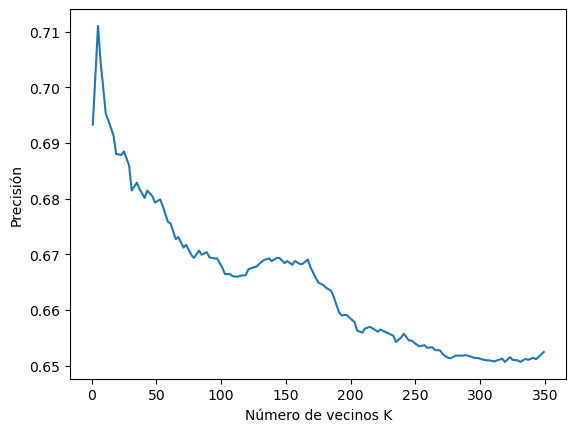

In [53]:
results = grid_search.cv_results_

# Extraer los valores de k y sus respectivas precisiones
ks = results['param_n_neighbors'].data
cv_scores = results['mean_test_score']

plt.plot(ks, cv_scores)
plt.xlabel('Número de vecinos K')
plt.ylabel('Precisión')
plt.show()

El número óptimo de vecinos es el número en el que se maximiza la precisión. En este caso es 5, y coincide con el valor que hemos utilizado en nuestras pruebas iniciales.

#### Árboles de Decisión

Para el árbol de decisión, realizaremos la afinación de hiperparámetros empleando `GridSearchCV` y variando:

- `max_leaf_nodes` entre 2 y 50 ambos inclusive
- `min_samples_split` entre 2 y 6 ambos inclusive
- `max_depth` entre 1 y 20 ambos inclusive

In [186]:
# Definir el rango de parámetros
param_grid = {
    'max_leaf_nodes': list(range(2, 51)),
    'min_samples_split': list(range(2, 7)),
    'max_depth': list(range(1, 21))
}

# Crear una instancia de DecisionTreeClassifier
decisionTree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0, class_weight='balanced')

# Configurar GridSearchCV y ajustar a los datos
grid_search = GridSearchCV(decisionTree, param_grid, scoring='accuracy', cv=10)
grid_search.fit(X_train_set_preprocessed, y_train_set)

C:\Users\maial\.conda\envs\unedenv\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=10,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              criterion='entropy',
                                              random_state=0),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4, 5, 6]},
             scoring='accuracy')

In [187]:
# Mejores parámetros encontrados
grid_search.best_params_

{'max_depth': 2, 'max_leaf_nodes': 3, 'min_samples_split': 2}

In [191]:
# Mejor puntuación (accuracy)
grid_search.best_score_

0.8335049194478945

#### Resumen y Conclusiones del Experimento 2

- KNN: El número óptimo de k es 5, y coincide con el utilizado en el Experimento 1.
- Árboles de Decisión: pendiente

### Experimento 3 - Reducción de la Dimensionalidad (1er intento)

#### Eliminar columnas

In [59]:
X_train_set.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [60]:
X_test_set.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

Dado que `latitude` y `longitude` pueden aportar unos datos parecidos a `neighbourhood_group` y `neighbourhood`, probaremos a eliminarlos.

También eliminaremos `reviews_per_month` al estar altamente correlacionada con `number_of_reviews`.

In [61]:
X_train_set_reduced = X_train_set.drop(columns=['latitude', 'longitude', 'reviews_per_month'])
X_test_set_reduced = X_test_set.drop(columns=['latitude', 'longitude', 'reviews_per_month'])

#### Preprocesamiento de Datos

In [62]:
# Aplicamos preprocesamiento
num_attribs = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood"]

num_pipeline = Pipeline([
    ("minmax_scaler", MinMaxScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set_reduced)

X_train_set_reduced_preprocessed = preprocessing.transform(X_train_set_reduced)
X_test_set_reduced_preprocessed = preprocessing.transform(X_test_set_reduced)

In [63]:
# Nombres de las columnas
preprocessing.get_feature_names_out()

array(['num__price', 'num__minimum_nights', 'num__number_of_reviews',
       'num__calculated_host_listings_count', 'num__availability_365',
       'cat__neighbourhood_group_Arganzuela',
       'cat__neighbourhood_group_Barajas',
       'cat__neighbourhood_group_Carabanchel',
       'cat__neighbourhood_group_Centro',
       'cat__neighbourhood_group_Chamartín',
       'cat__neighbourhood_group_Chamberí',
       'cat__neighbourhood_group_Ciudad Lineal',
       'cat__neighbourhood_group_Fuencarral - El Pardo',
       'cat__neighbourhood_group_Hortaleza',
       'cat__neighbourhood_group_Latina',
       'cat__neighbourhood_group_Moncloa - Aravaca',
       'cat__neighbourhood_group_Moratalaz',
       'cat__neighbourhood_group_Puente de Vallecas',
       'cat__neighbourhood_group_Retiro',
       'cat__neighbourhood_group_Salamanca',
       'cat__neighbourhood_group_San Blas - Canillejas',
       'cat__neighbourhood_group_Tetuán',
       'cat__neighbourhood_group_Usera',
       'cat__neighbo

In [64]:
X_train_set_reduced_preprocessed

<10655x152 sparse matrix of type '<class 'numpy.float64'>'
	with 62632 stored elements in Compressed Sparse Row format>

#### Naive Bayes - BernoulliNB

In [65]:
classifier = BernoulliNB()

# Aplicar el cross_val_score
bayes_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
bayes_accuracies

array([0.65853659, 0.65572233, 0.66885553, 0.6575985 , 0.68386492,
       0.68356808, 0.69014085, 0.70140845, 0.70328638, 0.67323944])

In [66]:
np.mean(bayes_accuracies)

0.677622105365149

No ha mejorado.

#### K-NN

In [67]:
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed, y_train_set.values.ravel(), scoring="accuracy", cv=10)
knn_accuracies

array([0.6988743 , 0.73733583, 0.72983114, 0.71388368, 0.72045028,
       0.71924883, 0.72676056, 0.7342723 , 0.7258216 , 0.72300469])

In [68]:
np.mean(knn_accuracies)

0.7229483215742234

Ha mejorado 0.1

#### Árboles de Decisión

In [69]:
classifier = DecisionTreeClassifier(
    criterion='entropy',
    random_state=0,
    class_weight='balanced',
    max_depth=7,
    max_leaf_nodes=50,
    min_samples_split=2
)
tree_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed, y_train_set, scoring="accuracy", cv=10)
tree_accuracies

array([0.83395872, 0.79080675, 0.83771107, 0.83302064, 0.76829268,
       0.76995305, 0.81314554, 0.83474178, 0.81971831, 0.75680751])

In [70]:
np.mean(tree_accuracies)

0.8058156065851015

Apenas cambia pero ha bajado un poco.

### Experimento 4 - Reducción de la Dimensionalidad (2o intento)

In [71]:
X_train_set.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [72]:
X_test_set.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

Dado que `latitude` y `longitude` pueden aportar unos datos parecidos a `neighbourhood_group` y `neighbourhood`, probaremos a eliminarlos.

También eliminaremos `neighbourhood_group`, que es una generalización de `neighbourhood`.

También eliminaremos `reviews_per_month` al estar altamente correlacionada con `number_of_reviews`.


- **Información duplicada**:
    - Localización en barrios y distritos, más la Longitud y latitud. Podríamos plantearnos quedarnos sólo con uno. Pero de entrada no vamos a descartar. Más adelante: Como conocimiento de experto, mejor quedarnos con grupos de barrios y barrios (más que latitud y longitud). De entre estos dos (grupo de barrios y barrios), si queremos que sea más eficiente, es mejor quedarnos con el grupo de barrios, pero sin embargo, perdemos información. En este caso, no pasa nada cuál de los dos elijamos si lo justificamos. La diferencia entre una y otra no es muy grande, y él ha dado cualquiera por válido.
    - number_of_reviews y reviews_per_month

In [73]:
X_train_set_reduced = X_train_set.drop(columns=['latitude', 'longitude', 'reviews_per_month', 'neighbourhood_group'])
X_test_set_reduced = X_test_set.drop(columns=['latitude', 'longitude', 'reviews_per_month', 'neighbourhood_group'])

#### Preprocesamiento de Datos

In [74]:
# Aplicamos preprocesamiento
num_attribs = ['price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

cat_attribs = ["neighbourhood"]

num_pipeline = Pipeline([
    ("minmax_scaler", MinMaxScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set_reduced)

X_train_set_reduced_preprocessed = preprocessing.transform(X_train_set_reduced)
X_test_set_reduced_preprocessed = preprocessing.transform(X_test_set_reduced)

In [75]:
# Nombres de las columnas
preprocessing.get_feature_names_out()

array(['num__price', 'num__minimum_nights', 'num__number_of_reviews',
       'num__calculated_host_listings_count', 'num__availability_365',
       'cat__neighbourhood_Abrantes', 'cat__neighbourhood_Acacias',
       'cat__neighbourhood_Adelfas', 'cat__neighbourhood_Aeropuerto',
       'cat__neighbourhood_Aguilas',
       'cat__neighbourhood_Alameda de Osuna',
       'cat__neighbourhood_Almagro', 'cat__neighbourhood_Almenara',
       'cat__neighbourhood_Almendrales', 'cat__neighbourhood_Aluche',
       'cat__neighbourhood_Ambroz', 'cat__neighbourhood_Amposta',
       'cat__neighbourhood_Apostol Santiago',
       'cat__neighbourhood_Arapiles', 'cat__neighbourhood_Aravaca',
       'cat__neighbourhood_Arcos', 'cat__neighbourhood_Argüelles',
       'cat__neighbourhood_Atocha', 'cat__neighbourhood_Bellas Vistas',
       'cat__neighbourhood_Berruguete', 'cat__neighbourhood_Buenavista',
       'cat__neighbourhood_Butarque', 'cat__neighbourhood_Campamento',
       'cat__neighbourhood_Canillas',

In [76]:
X_train_set_reduced_preprocessed

<10655x131 sparse matrix of type '<class 'numpy.float64'>'
	with 51977 stored elements in Compressed Sparse Row format>

#### Naive Bayes - BernoulliNB

In [77]:
classifier = BernoulliNB()

# Aplicar el cross_val_score
bayes_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed.toarray(), y_train_set.values.ravel(), scoring="accuracy", cv=10)
bayes_accuracies

array([0.68855535, 0.67542214, 0.67542214, 0.67636023, 0.7195122 ,
       0.69201878, 0.70798122, 0.69671362, 0.71267606, 0.68920188])

In [78]:
np.mean(bayes_accuracies)

0.6933863594323919

Ha mejorado 0.2. Aún así sigue siendo bajo.

#### K-NN

In [79]:
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed, y_train_set.values.ravel(), scoring="accuracy", cv=10)
knn_accuracies

array([0.69981238, 0.73733583, 0.72983114, 0.71388368, 0.72045028,
       0.72112676, 0.72769953, 0.7342723 , 0.7258216 , 0.72676056])

In [80]:
np.mean(knn_accuracies)

0.7236994071999225

No ha mejorado.

#### Árboles de Decisión

In [81]:
classifier = DecisionTreeClassifier(
    criterion='entropy',
    random_state=0,
    class_weight='balanced',
    max_depth=7,
    max_leaf_nodes=50,
    min_samples_split=2
)
tree_accuracies = cross_val_score(classifier, X_train_set_reduced_preprocessed, y_train_set, scoring="accuracy", cv=10)
tree_accuracies

array([0.80863039, 0.77673546, 0.80581614, 0.815197  , 0.78236398,
       0.76713615, 0.81784038, 0.78967136, 0.79342723, 0.75399061])

In [82]:
np.mean(tree_accuracies)

0.791080869205225

Apenas cambia pero ha bajado un poco más.

## Comparación de los Resultados Obtenidos
- Añadir gráficos que muestren los resultados, para poder compararlos.

## Conclusiones

**Notas importantes:**
- Cross_val_score hace estratificación?

**Futuras líneas:**
- Tratamiento de latitude y longitude como dice el libro, creando clusteres y metiendo dichos clusteres en el preprocesamiento de datos.
- Aplicar el oversampling.

- **Tratamiento de Latitud y Longitud**: en un principio los probaremos tal cual. Posteriormente, la latitud y longitud se pueden utilizar para crear una nueva característica que capture la similitud entre viviendas según su ubicación geográfica.
    - **`ClusterSimilarity`** crea un modelo de clustering basado en las coordenadas de latitud y longitud.
    - **`n_clusters=10`** especifica que los datos de ubicación se dividirán en 10 clusters. Cada cluster representa una región geográfica distinta.
    - **`gamma=1.`** controla el alcance de la influencia entre los clusters en la métrica de similitud. Un valor de gamma más alto puede hacer que los puntos estén más asociados con su propio cluster y menos con clusters lejanos.

`cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)`

`("geo", cluster_simil, ["latitude", "longitude"])`


**Notas:**

-	Resumen de todos los resultados: gráfico de barras, o tabla con resultados de exactitudes, etc.
-	Características de cada algoritmo y aclarar todo lo que hemos hecho
-	Mejor candidato elegido, por qué, qué sesgos se han introducido, restricciones del modelo (filtrado de datos, número de máquinas necesarias, etc.)
-	Cómo lo llevaríamos a PROD y por qué (limitaciones de hardware, coste computacional, etc.)
-	Referencias/bibliografía
